# Figure 4

In [1]:
import matplotlib as mpl
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import ndimage, stats
import seaborn as sns

# Remove top and right axis from plots:
mpl.rcParams['axes.spines.top'] = False

# blurr calculates the convolution of an image with a Gaussian
# The cross section FWHM is the full width at half-maximum
# filter normalized so that integral of filter = 1.0

def Gauss1D(FWHM,RFsize):
    myrange=RFsize/2
    sigma=FWHM/(2.0*np.sqrt(2*np.log(2)))
    x=np.arange(-myrange,(myrange+1),1)*1.0
    z=np.exp(-x**2/(2*(sigma**2)))
    z=z/np.sum(z)
    return z

def blurr(inp_image,FWHM):
    if inp_image.ndim==1: z=Gauss1D(FWHM,4*FWHM)
    if inp_image.ndim==2: z=Gauss2D(FWHM,4*FWHM)
    result=scipy.ndimage.convolve(inp_image,z)
    return result

def smooth_data(data):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            for k in range(data.shape[2]):
                data[i,j,k] = blurr(data[i,j,k],30)
    return data

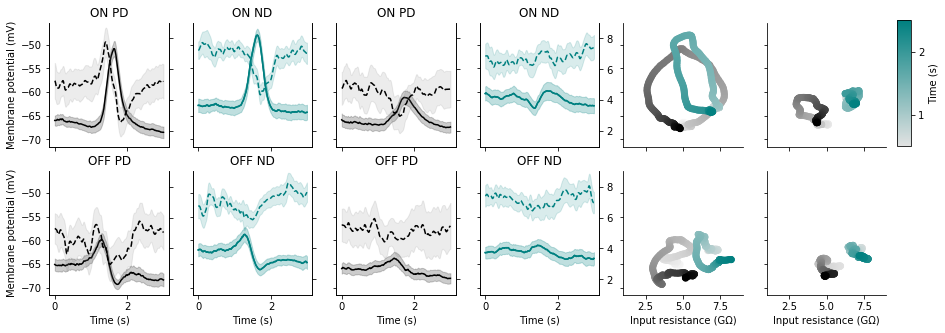

In [2]:
# Figure 4a, b:
# Load voltage data: 
T4_vm_gfp = np.load('fig4_T4_vm_gfp.npy') # GFP
T4_vm_gluclarnai = np.load('fig4_T4_vm_gluclarnai.npy') # GluClα RNAi

# Load and smooth input resistance data:
T4_rin_gfp = smooth_data(np.load('fig4_T4_rin_gfp.npy')) # GFP
T4_rin_gluclarnai = smooth_data(np.load('fig4_T4_rin_gluclarnai.npy')) # GluClα RNAi

# Define colour maps:
cmaps = ['Greys', mpl.colors.LinearSegmentedColormap.from_list('GluCla_RNAi', ['#e3e3e3', 'teal'], N=256)]

# Define stimulus conditions:
pols = ['ON', 'OFF'] # polarities
dirs = ['PD', 'ND'] # directions

# Exclude the voltages of all control (GFP) cells for which no input resistance data exists:
T4v = np.full_like(T4_rin_gfp, np.nan)                # create array filled with NaNs of the same size as T4_rin_gfp
T4_vm_gfp = np.where(~np.isnan(T4_rin_gfp), T4_vm_gfp, T4v) # fill it with voltages only where input resistances exist


# Specify structure:
titles = [['ON PD', 'ON ND'],
          ['OFF PD', 'OFF ND']]
fs = 1000 # sampling frequency (Hz)
ds = 10 # downsampling for plotting 
m = 50  # margin for plotting


fig, ax = plt.subplots(2,6, figsize=(15,5), sharey=True)
for idxp, p in enumerate(pols):
        for idxd, d in enumerate(dirs):
            # Define data for respective polarity and direction:
            # GFP:
            gfp_v = np.nanmean(T4_vm_gfp[:,idxp,idxd,::ds], axis=0) 
            gfp_r = np.nanmean(T4_rin_gfp[:,idxp,idxd,::ds], axis=0)
            gfp_v_sem = stats.sem(T4_vm_gfp[:,idxp,idxd,::ds], axis =0, nan_policy='omit')
            gfp_r_sem = stats.sem(T4_rin_gfp[:,idxp,idxd,::ds], axis=0, nan_policy='omit')
            
            # RNAi:
            rnai_v = np.nanmean(T4_vm_gluclarnai[:,idxp,idxd,::ds], axis=0)
            rnai_r = np.nanmean(T4_rin_gluclarnai[:,idxp,idxd,::ds], axis=0)
            rnai_v_sem = stats.sem(T4_vm_gluclarnai[:,idxp,idxd,::ds], axis =0, nan_policy='omit')
            rnai_r_sem = stats.sem(T4_rin_gluclarnai[:,idxp,idxd,::ds], axis=0, nan_policy='omit')
            
            # Define time axis:
            x = np.arange(0,len(gfp_v)/fs*ds, 0.001*ds)
            
            # Plot GFP data:
            ax[idxp,2*idxd].plot(x, gfp_v, c='k', alpha = 1, label = 'GFP')
            ax[idxp,2*idxd].fill_between(x, gfp_v+gfp_v_sem, gfp_v-gfp_v_sem, color='k', alpha=0.20, edgecolor='none')
            bx = ax[idxp,2*idxd].twinx()
            bx.plot(x, gfp_r, c='k', linestyle='--', alpha = 1.0)
            bx.fill_between(x, gfp_r+gfp_r_sem, gfp_r-gfp_r_sem, color='grey', alpha=0.15, edgecolor='none')
            bx.set_ylim(1,9)
            if 2*idxd < 3:
                bx.set_yticklabels([])
            
            # Plot GluClα RNAi data:
            ax[idxp,2*idxd+1].plot(x,rnai_v, c='teal', alpha = 1, label = 'GluClα RNAi')
            ax[idxp,2*idxd+1].plot(x,rnai_v, c='teal', alpha = 1, label = 'GluClα RNAi')
            ax[idxp,2*idxd+1].fill_between(x, rnai_v+rnai_v_sem, rnai_v-rnai_v_sem, color='teal', alpha=0.25, edgecolor='none')
            bx = ax[idxp,0+2*idxd+1].twinx()
            bx.plot(x,rnai_r,c='teal', linestyle='--', alpha = 1.0)
            bx.fill_between(x, rnai_r+rnai_r_sem, rnai_r-rnai_r_sem, color='teal', alpha=0.15, edgecolor='none')
            bx.set_ylim(1,9)
            if 2*idxd+1 < 3:
                bx.set_yticklabels([])
            
            # Set titles:
            ax[idxp,idxd].set_title(titles[idxp][idxd])
            ax[idxp,idxd+2].set_title(titles[idxp][idxd])

            # Plot resistance vs. voltage:
            for idx, g in enumerate([[gfp_r[m:-m], gfp_v[m:-m]], [rnai_r[m:-m], rnai_v[m:-m]]]):
                points = np.array([g[0], g[1]]).T.reshape(-1, 1, 2)
                segments = np.concatenate([points[:-1], points[1:]], axis=1)
                   
                # Create a continuous scale to map from data points to colors
                norm = plt.Normalize(x[m:-m].min(), x[m:-m].max())
                cmap_ = cmaps[idx]
                lc = LineCollection(segments, cmap=cmap_, norm=norm)
                   
                # Set the values used for colormapping
                lc.set_array(x[m:-m])
                lc.set_linewidth(7)
                lc.set_capstyle('round')
                
                line = ax[idxp,idxd+4].add_collection(lc)
                
            ax[idxp,idxd+4].set_xlim(1,9)
            
# Label and remove axes where necessary:   
for i in range(2):
    for j in range(4):
        ax[i,0].set_ylabel("Membrane potential (mV)")
        ax[1,j].set_xlabel("Time (s)")
    for j in range(4,6):
        ax[i,j].spines['right'].set_visible(False)
        ax[1,j].set_xlabel("Input resistance (GΩ)")
for j in range(6): 
        ax[0,j].set_xticklabels([])

# Add colourbar:
cbar_ax = fig.add_axes([0.91, 0.537, 0.013, 0.35])
cb = fig.colorbar(lc, cax=cbar_ax)
cb.set_label("Time (s)")
cb.set_ticks([0, 1, 2, 3]);

#plt.savefig('fig4.pdf');